# 🌊 Addressing Dataset Imbalance in Ocean Image Classification Using Augmentation Techniques

**Techniques Used:**
- Technique 1: Rotation & Flipping (Basic Augmentation)
- Technique 2: Color Jitter & Brightness (Photometric Augmentation)
- Technique 3: CutMix (Advanced Augmentation)

**Model:** ResNet18 (Transfer Learning)

**Dataset:** Sea Animals Dataset from Kaggle

## Step 1: Install & Import Libraries

In [ ]:
# Install kaggle to download dataset
!pip install kaggle -q

import os, random, copy, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision
from torchvision import datasets, transforms, models
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, accuracy_score)
from collections import Counter

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')

✅ Using device: cuda


## Step 2: Download Dataset from Kaggle
> ⚠️ Upload your `kaggle.json` API key file when prompted.

In [ ]:
from google.colab import files

print("📂 Upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download Sea Animals Dataset
!kaggle datasets download -d vencerlanz09/sea-animals-image-dataste --unzip -p /content/sea_animals
print("✅ Dataset downloaded!")

📂 Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vencerlanz09/sea-animals-image-dataste
License(s): other
100% 312M/312M [00:09<00:00, 33.0MB/s]

✅ Dataset downloaded!


## Step 3: Explore Dataset & Visualize Class Imbalance

Found classes at: /content/sea_animals

📊 Total Classes: 23
Class Distribution:
  Seal: 414 images
  Seahorse: 478 images
  Penguin: 482 images
  Squid: 483 images
  Shrimp: 488 images
  Fish: 494 images
  Clams: 497 images
  Eel: 497 images
  Crabs: 499 images
  Lobster: 499 images
  Starfish: 499 images
  Corals: 500 images
  Nudibranchs: 500 images
  Otter: 500 images
  Sea Rays: 517 images
  Puffers: 531 images
  Octopus: 562 images
  Whale: 572 images
  Sea Urchins: 579 images
  Sharks: 590 images
  Dolphin: 782 images
  Jelly Fish: 845 images
  Turtle_Tortoise: 1903 images


/tmp/ipykernel_2940/4258466983.py:26: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2940/4258466983.py:27: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig('class_distribution.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


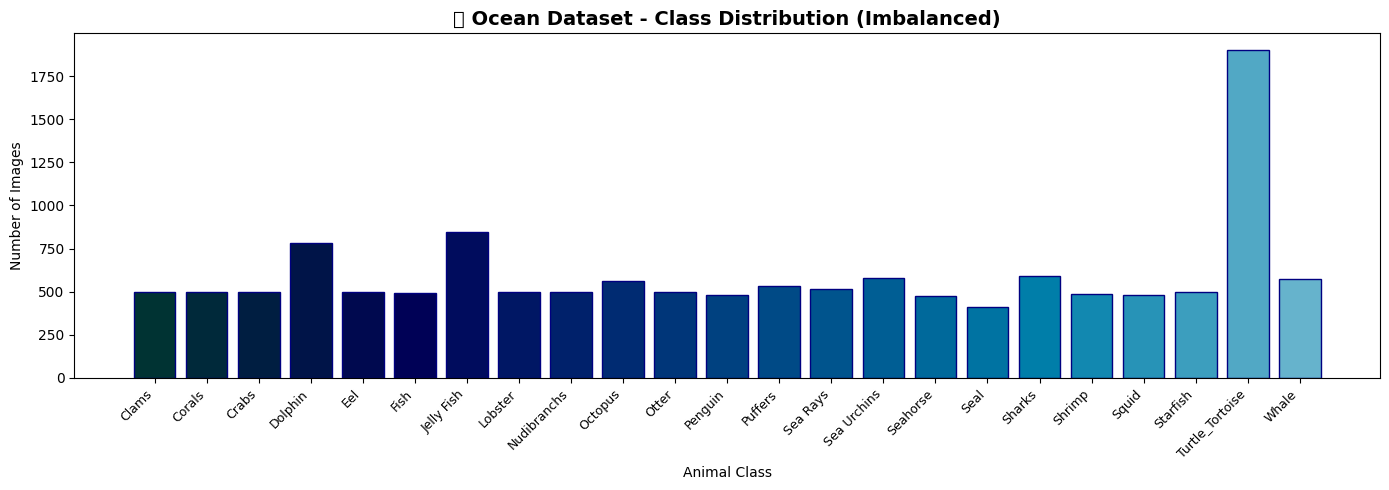

✅ Class distribution plotted!


In [ ]:
DATA_DIR = '/content/sea_animals'

# Find the correct subfolder
for root, dirs, files_list in os.walk(DATA_DIR):
    if dirs:
        print(f'Found classes at: {root}')
        CLASS_DIR = root
        break

classes = sorted(os.listdir(CLASS_DIR))
class_counts = {cls: len(os.listdir(os.path.join(CLASS_DIR, cls))) for cls in classes}

print(f'\n📊 Total Classes: {len(classes)}')
print('Class Distribution:')
for k, v in sorted(class_counts.items(), key=lambda x: x[1]):
    print(f'  {k}: {v} images')

# Plot class distribution
plt.figure(figsize=(14, 5))
colors = plt.cm.ocean(np.linspace(0.2, 0.8, len(classes)))
plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='navy')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('🌊 Ocean Dataset - Class Distribution (Imbalanced)', fontsize=14, fontweight='bold')
plt.xlabel('Animal Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('✅ Class distribution plotted!')

## Step 4: Define 3 Augmentation Techniques

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = len(classes)

# ─────────────────────────────────────────────
# TECHNIQUE 1: Rotation & Flipping
# ─────────────────────────────────────────────
transform_technique1 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ─────────────────────────────────────────────
# TECHNIQUE 2: Color Jitter & Brightness
# ─────────────────────────────────────────────
transform_technique2 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ─────────────────────────────────────────────
# TECHNIQUE 3: CutMix (applied during training loop)
# Base transform — CutMix is applied inside the train function
# ─────────────────────────────────────────────
transform_technique3 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation transform (no augmentation)
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print('✅ All 3 augmentation transforms defined!')

✅ All 3 augmentation transforms defined!


## Step 5: CutMix Helper Function

In [ ]:
def cutmix_data(x, y, alpha=1.0):
    """Apply CutMix augmentation to a batch."""
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    rand_index = torch.randperm(batch_size).to(DEVICE)

    y_a, y_b = y, y[rand_index]

    W, H = x.size(3), x.size(2)
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    x[:, :, bby1:bby2, bbx1:bbx2] = x[rand_index, :, bby1:bby2, bbx1:bbx2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))

    return x, y_a, y_b, lam

def cutmix_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print('✅ CutMix helper defined!')

✅ CutMix helper defined!


## Step 6: Dataset Loader with Weighted Sampler (handles imbalance)

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

def get_loaders(transform_train, use_sampler=True):
    full_dataset = datasets.ImageFolder(CLASS_DIR, transform=transform_train)
    val_dataset  = datasets.ImageFolder(CLASS_DIR, transform=transform_val)

    # 80/20 split
    indices = list(range(len(full_dataset)))
    labels  = [full_dataset.targets[i] for i in indices]
    train_idx, val_idx = train_test_split(
        indices, test_size=0.2, stratify=labels, random_state=SEED)

    train_set = Subset(full_dataset, train_idx)
    val_set   = Subset(val_dataset,  val_idx)

    if use_sampler:
        train_labels = [full_dataset.targets[i] for i in train_idx]
        class_sample_count = Counter(train_labels)
        weight = {cls: 1.0 / count for cls, count in class_sample_count.items()}
        sample_weights = [weight[t] for t in train_labels]
        sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
        train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler)
    else:
        train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, full_dataset.classes

print('✅ Data loader function ready!')

✅ Data loader function ready!


## Step 7: Model Definition (ResNet18 Transfer Learning)

In [ ]:
def get_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace final FC layer
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model.to(DEVICE)

print('✅ ResNet18 model builder ready!')

✅ ResNet18 model builder ready!


## Step 8: Training & Evaluation Functions

In [ ]:
def train_model(model, train_loader, val_loader, use_cutmix=False, epochs=EPOCHS):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            if use_cutmix and random.random() > 0.5:
                inputs, y_a, y_b, lam = cutmix_data(inputs, labels)
                outputs = model(inputs)
                loss = cutmix_criterion(criterion, outputs, y_a, y_b, lam)
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        scheduler.step()
        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'  Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    return history


def evaluate_model(model, val_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm   = confusion_matrix(all_labels, all_preds)
    return acc, f1, prec, rec, cm

print('✅ Training and evaluation functions ready!')

✅ Training and evaluation functions ready!


## Step 9: Train All 3 Techniques
> ⏱️ This may take ~15-30 mins depending on dataset size and GPU

In [ ]:
results = {}
histories = {}
val_loaders = {}

techniques = [
    ('Rotation & Flipping',      transform_technique1, False),
    ('Color Jitter & Brightness',transform_technique2, False),
    ('CutMix',                   transform_technique3, True),
]

for name, transform, use_cutmix in techniques:
    print(f'\n{'='*55}')
    print(f'🔧 Technique: {name}')
    print(f'{'='*55}')

    train_loader, val_loader, class_names = get_loaders(transform)
    model = get_model(NUM_CLASSES)
    history = train_model(model, train_loader, val_loader, use_cutmix=use_cutmix)

    acc, f1, prec, rec, cm = evaluate_model(model, val_loader)
    results[name] = {'Accuracy': acc, 'F1 Score': f1,
                     'Precision': prec, 'Recall': rec, 'CM': cm}
    histories[name] = history
    val_loaders[name] = val_loader

    print(f'\n📊 Results for {name}:')
    print(f'   Accuracy  : {acc:.4f}')
    print(f'   F1 Score  : {f1:.4f}')
    print(f'   Precision : {prec:.4f}')
    print(f'   Recall    : {rec:.4f}')

print('\n✅ All techniques trained and evaluated!')


🔧 Technique: Rotation & Flipping
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


  Epoch [1/10] | Train Loss: 2.0477 | Val Loss: 1.1802 | Val Acc: 0.6726
  Epoch [2/10] | Train Loss: 1.4966 | Val Loss: 1.0592 | Val Acc: 0.6952
  Epoch [3/10] | Train Loss: 1.4055 | Val Loss: 0.9954 | Val Acc: 0.7051
  Epoch [4/10] | Train Loss: 1.3613 | Val Loss: 0.9728 | Val Acc: 0.7109
  Epoch [5/10] | Train Loss: 1.3295 | Val Loss: 0.9536 | Val Acc: 0.7207
  Epoch [6/10] | Train Loss: 1.3118 | Val Loss: 0.9456 | Val Acc: 0.7211
  Epoch [7/10] | Train Loss: 1.3143 | Val Loss: 0.9354 | Val Acc: 0.7207
  Epoch [8/10] | Train Loss: 1.3287 | Val Loss: 0.9133 | Val Acc: 0.7306
  Epoch [9/10] | Train Loss: 1.2801 | Val Loss: 0.9171 | Val Acc: 0.7273
  Epoch [10/10] | Train Loss: 1.3131 | Val Loss: 0.9131 | Val Acc: 0.7310

📊 Results for Rotation & Flipping:
   Accuracy  : 0.7310
   F1 Score  : 0.7329
   Precision : 0.7443
   Recall    : 0.7310

🔧 Technique: Color Jitter & Brightness
  Epoch [1/10] | Train Loss: 1.8714 | Val Loss: 1.0584 | Val Acc: 0.7080
  Epoch [2/10] | Train Loss: 1.3

## Step 10: 📊 Final Comparison – Bar Chart (Accuracy, F1, Precision, Recall)

/tmp/ipykernel_2940/3393695658.py:26: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2940/3393695658.py:27: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig('technique_comparison.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


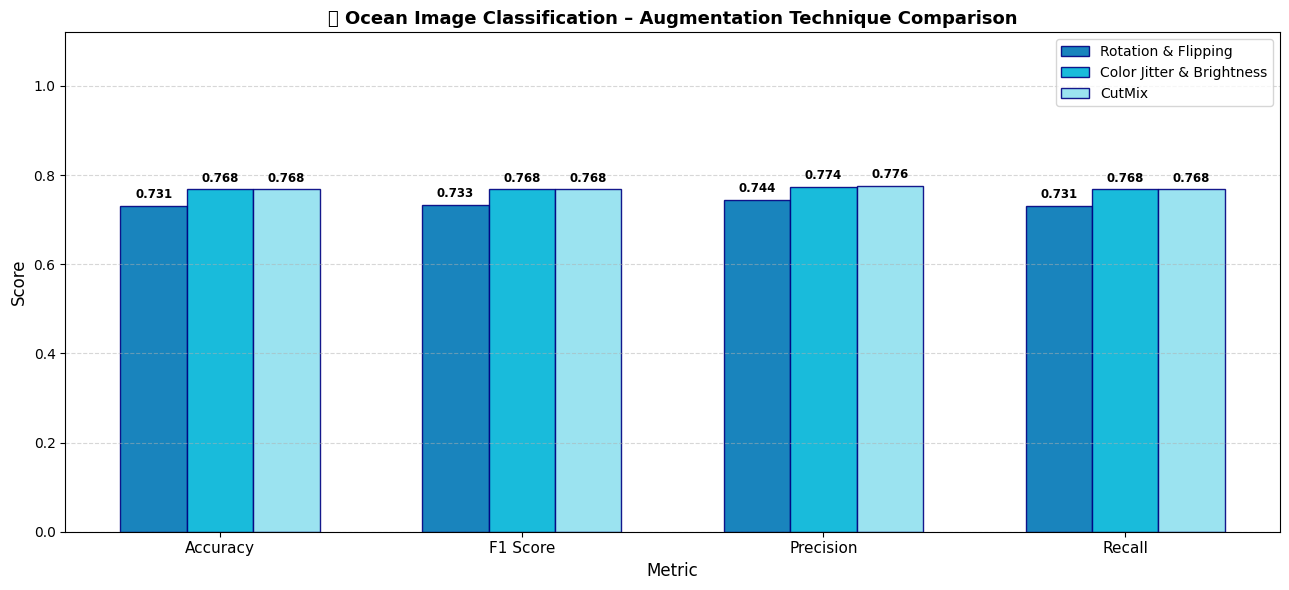

✅ Comparison chart saved!


In [ ]:
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
technique_names = list(results.keys())
colors = ['#0077B6', '#00B4D8', '#90E0EF']

x = np.arange(len(metrics))
width = 0.22

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, color) in enumerate(zip(technique_names, colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=color, edgecolor='navy', alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('🌊 Ocean Image Classification – Augmentation Technique Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('technique_comparison.png', dpi=150)
plt.show()
print('✅ Comparison chart saved!')

## Step 11: 📈 Training Loss & Accuracy Curves (per technique)

/tmp/ipykernel_2940/2737119088.py:26: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2940/2737119088.py:27: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150)


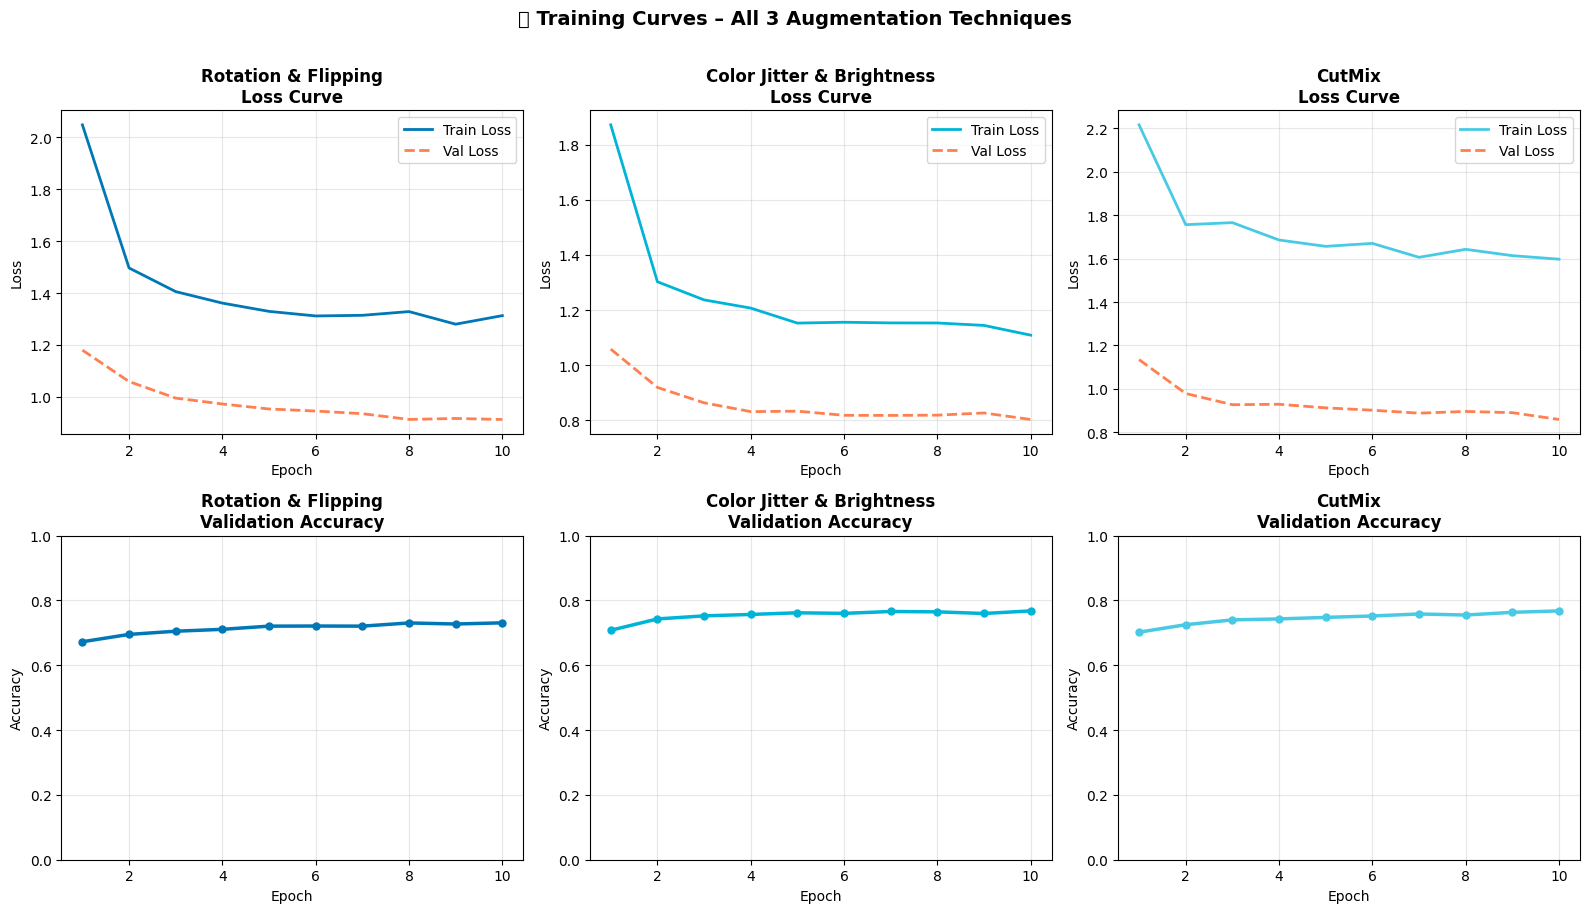

✅ Training curves saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
ocean_colors = ['#0077B6', '#00B4D8', '#48CAE4']

for col, (name, color) in enumerate(zip(technique_names, ocean_colors)):
    h = histories[name]
    ep = range(1, EPOCHS + 1)

    # Loss
    axes[0, col].plot(ep, h['train_loss'], label='Train Loss', color=color, linewidth=2)
    axes[0, col].plot(ep, h['val_loss'],   label='Val Loss',   color='coral', linewidth=2, linestyle='--')
    axes[0, col].set_title(f'{name}\nLoss Curve', fontweight='bold')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    # Accuracy
    axes[1, col].plot(ep, h['val_acc'], color=color, linewidth=2.5, marker='o', markersize=5)
    axes[1, col].set_title(f'{name}\nValidation Accuracy', fontweight='bold')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].set_ylim(0, 1)
    axes[1, col].grid(alpha=0.3)

plt.suptitle('🌊 Training Curves – All 3 Augmentation Techniques', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('✅ Training curves saved!')

## Step 12: 🔥 Confusion Matrices

/tmp/ipykernel_2940/3535128468.py:18: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2940/3535128468.py:19: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrices.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


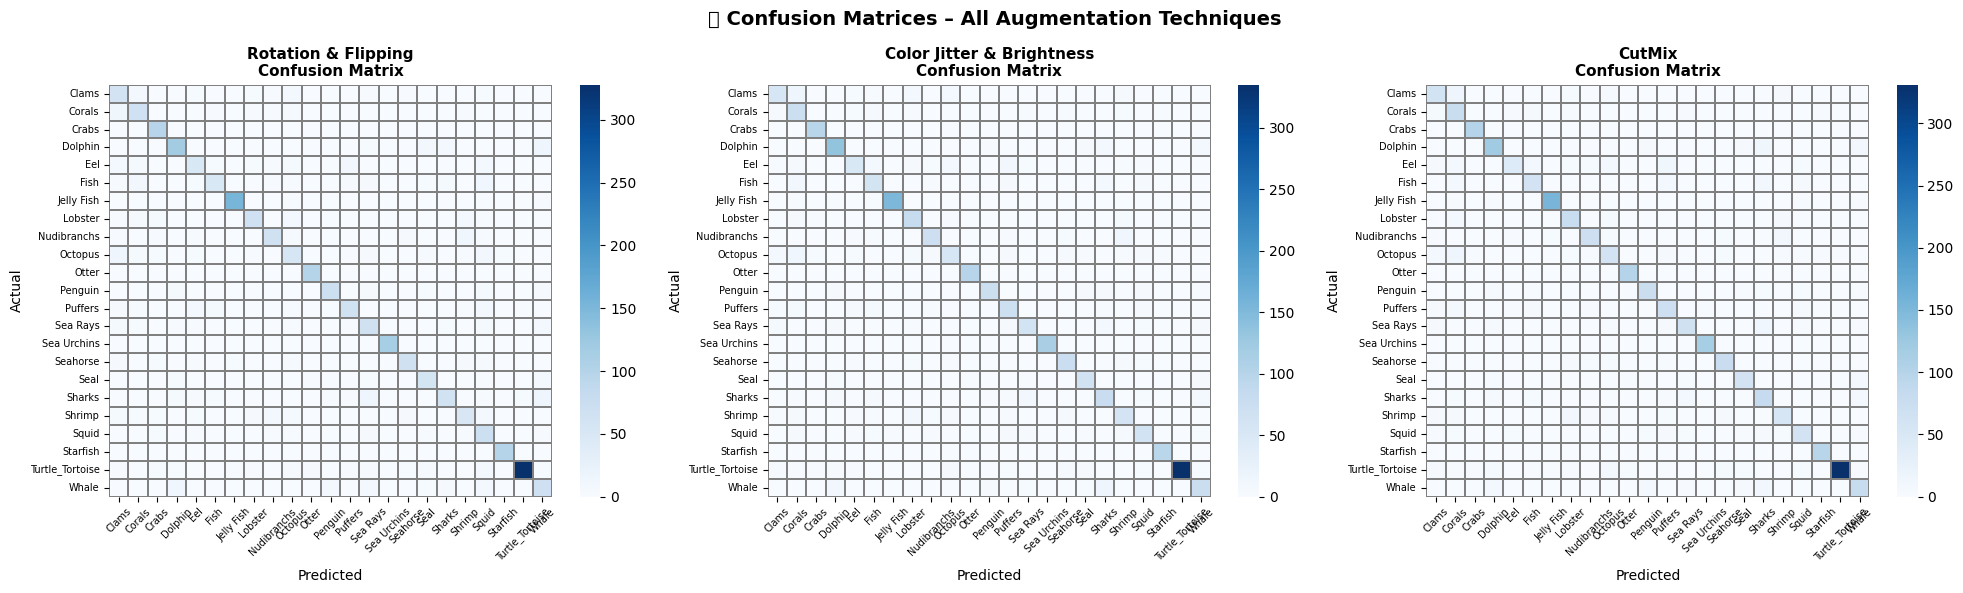

✅ Confusion matrices saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, _) in zip(axes, results.items()):
    cm = results[name]['CM']
    # Show top-10 classes for readability if many classes
    sns.heatmap(cm, ax=ax, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.3, linecolor='gray',
                annot=(len(class_names) <= 12),
                fmt='d' if len(class_names) <= 12 else '')
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('🌊 Confusion Matrices – All Augmentation Techniques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print('✅ Confusion matrices saved!')

## Step 13: 🕸️ Radar Chart – Metric Comparison

/tmp/ipykernel_2940/2083528595.py:22: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2940/2083528595.py:23: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig('radar_chart.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


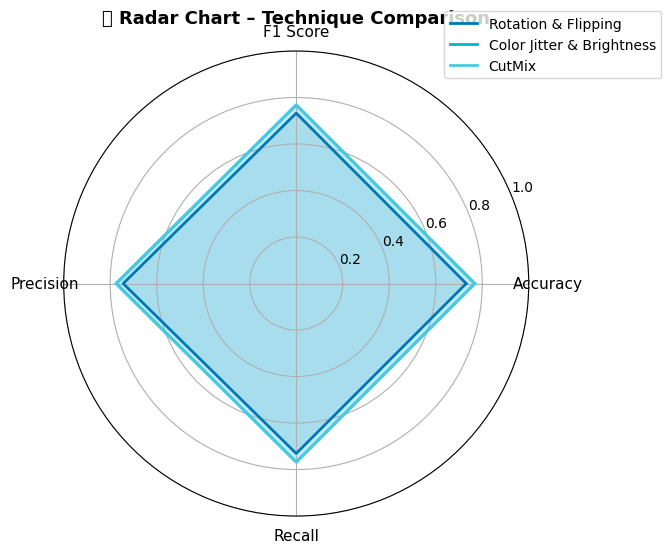

✅ Radar chart saved!


In [ ]:
from matplotlib.patches import FancyArrowPatch

metric_labels = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
N = len(metric_labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
radar_colors = ['#0077B6', '#00B4D8', '#48CAE4']

for (name, color) in zip(technique_names, radar_colors):
    vals = [results[name][m] for m in metric_labels]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, linestyle='solid', label=name, color=color)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('🌊 Radar Chart – Technique Comparison', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150)
plt.show()
print('✅ Radar chart saved!')

## Step 14: 📋 Final Summary Table

In [ ]:
print('\n' + '='*65)
print('         🌊 FINAL RESULTS SUMMARY TABLE')
print('='*65)
print(f'{"Technique":<28} {"Accuracy":>9} {"F1 Score":>9} {"Precision":>10} {"Recall":>8}')
print('-'*65)
best_f1 = max(results, key=lambda k: results[k]['F1 Score'])
for name, r in results.items():
    star = ' ⭐' if name == best_f1 else ''
    print(f'{name:<28} {r["Accuracy"]:>9.4f} {r["F1 Score"]:>9.4f} {r["Precision"]:>10.4f} {r["Recall"]:>8.4f}{star}')
print('='*65)
print(f'\n🏆 Best Technique (by F1 Score): {best_f1}')
print('\n✅ Project Complete!')


         🌊 FINAL RESULTS SUMMARY TABLE
Technique                     Accuracy  F1 Score  Precision   Recall
-----------------------------------------------------------------
Rotation & Flipping             0.7310    0.7329     0.7443   0.7310
Color Jitter & Brightness       0.7678    0.7681     0.7739   0.7678 ⭐
CutMix                          0.7678    0.7678     0.7762   0.7678

🏆 Best Technique (by F1 Score): Color Jitter & Brightness

✅ Project Complete!
